# 07 · Evaluate the SBI posterior trained on the spectra (Pk)

Uses `config.EVAL["n_samples"]` posterior samples per observation on
* **val**: the v1 + v2 validation sets (in distribution),
* **test**: the C-grid set (every cosmology on a regular grid of C over its full prior).

**Sampling is the slow step.** For full-size runs, do it from a terminal first (resumable, bounded memory):

```bash
nohup python -m clmini.sample_posteriors --kind pk > sample_pk.log 2>&1 &
```

This notebook then just loads `outputs/<run>/sbi_pk/samples_{val,test}.npz`. If they are missing, it
computes them here, which gives the same result. It writes `metrics.json` and PNG figures to
`outputs/<run>/sbi_pk/`. Next: `08_evaluate_SBI_latents.ipynb`.

In [1]:
import config as cfg
from clmini import data, cl, sbi_tools, metrics, plots
print(f"run = {cfg.RUN_NAME} | data -> {cfg.DATA_DIR.relative_to(cfg.ROOT)} | outputs -> {cfg.OUT_DIR.relative_to(cfg.ROOT)}")
from clmini import sample_posteriors
KIND, LABEL = "pk", "Pk"
print("inferred parameters:", cfg.SBI_PARAMS)

run = full | data -> data/full | outputs -> outputs/full
inferred parameters: ['A', 'B', 'C']


## Load (or compute) the posterior samples

In [2]:
samples = sample_posteriors.load_or_sample(cfg, KIND)
results = {f"{LABEL} val": samples["val"], f"{LABEL} test": samples["test"]}

[pk/val] no up-to-date samples found -> computing them now. This is the slow step; for full runs prefer a terminal:  python -m clmini.sample_posteriors --kind pk
[pk/val] 4096 observations x 1000 samples, 64 chunks of 64 (1 already done)


pk/val:   0%|          | 0/63 [00:00<?, ?chunk/s]

  chunk    1:   1.1 s | acceptance mean 0.920 min 0.372 | fallback 0/64
  chunk    2:   1.3 s | acceptance mean 0.885 min 0.231 | fallback 0/64
  chunk    3:   1.2 s | acceptance mean 0.916 min 0.379 | fallback 0/64
  chunk    4:   1.2 s | acceptance mean 0.928 min 0.495 | fallback 0/64
  chunk    5:   1.2 s | acceptance mean 0.888 min 0.354 | fallback 0/64
  chunk    6:   1.2 s | acceptance mean 0.901 min 0.235 | fallback 0/64
  chunk    7:   1.4 s | acceptance mean 0.853 min 0.130 | fallback 0/64
  chunk    8:   1.2 s | acceptance mean 0.905 min 0.443 | fallback 0/64
  chunk    9:   1.2 s | acceptance mean 0.918 min 0.386 | fallback 0/64
  chunk   10:   1.5 s | acceptance mean 0.858 min 0.128 | fallback 0/64
  chunk   11:   1.1 s | acceptance mean 0.899 min 0.222 | fallback 0/64
  chunk   12:   1.3 s | acceptance mean 0.890 min 0.185 | fallback 0/64
  chunk   13:   1.2 s | acceptance mean 0.919 min 0.251 | fallback 0/64
  chunk   14:   1.2 s | acceptance mean 0.878 min 0.365 | fallba

pk/test:   0%|          | 0/164 [00:00<?, ?chunk/s]

  chunk    0:   1.6 s | acceptance mean 0.474 min 0.000 | fallback 21/64
  chunk    1:   2.4 s | acceptance mean 0.544 min 0.000 | fallback 21/64
  chunk    2:   2.0 s | acceptance mean 0.732 min 0.000 | fallback 9/64
  chunk    3:   3.1 s | acceptance mean 0.435 min 0.000 | fallback 25/64
  chunk    4:   2.0 s | acceptance mean 0.595 min 0.000 | fallback 10/64
  chunk    5:   2.3 s | acceptance mean 0.597 min 0.000 | fallback 18/64
  chunk    6:   3.3 s | acceptance mean 0.376 min 0.000 | fallback 21/64
  chunk    7:   1.5 s | acceptance mean 0.713 min 0.000 | fallback 13/64
  chunk    8:   3.5 s | acceptance mean 0.466 min 0.000 | fallback 25/64
  chunk    9:   3.3 s | acceptance mean 0.564 min 0.000 | fallback 12/64
  chunk   10:   2.4 s | acceptance mean 0.625 min 0.000 | fallback 15/64
  chunk   11:   1.7 s | acceptance mean 0.582 min 0.000 | fallback 18/64
  chunk   12:   2.0 s | acceptance mean 0.334 min 0.000 | fallback 29/64
  chunk   13:   1.6 s | acceptance mean 0.601 min 0.

## Rejection acceptance and fallback against C
Acceptance = fraction of estimator samples inside the prior. Observations below `EVAL["min_acceptance"]` keep the raw (unrejected, unclipped) samples and are flagged as *fallback*: their posterior is unreliable.

PosixPath('outputs/full/sbi_pk/fallback_vs_C.png')

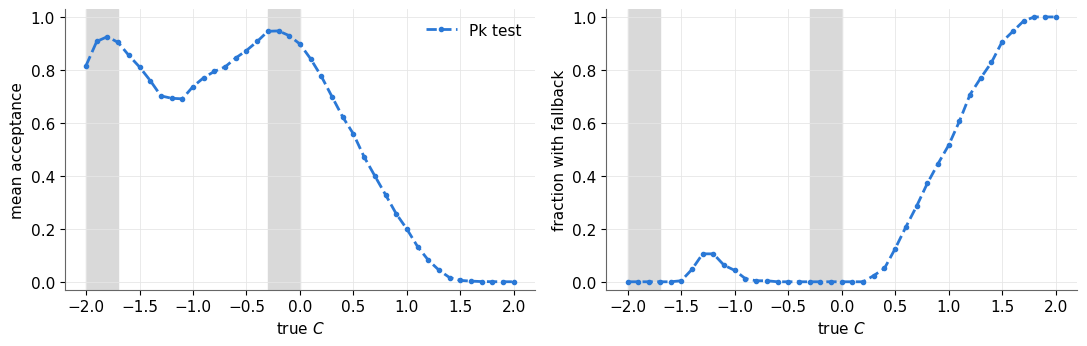

In [3]:
fig = plots.fallback_vs_c(cfg, {f"{LABEL} test": results[f"{LABEL} test"]})
metrics.save_fig(cfg, fig, f"sbi_{KIND}/fallback_vs_C")

## Summary metrics
`err` = |median − true| / prior width, `2sigma` = posterior width / prior width, `bias` = (median − true) / σ, `coverage_68` should be ≈ 0.68, `max_calibration_error` ≈ 0 when calibrated.

In [4]:
table, summary = metrics.metrics_table(cfg, results)
metrics.save_json(cfg, summary, f"sbi_{KIND}/metrics.json")
table

median_err_over_prior  median_2sigma_over_prior  mean_bias  \
set     param                                                               
Pk val  A                      0.062                     0.152      0.059   
        B                      0.035                     0.089     -0.157   
        C                      0.016                     0.039      0.038   
Pk test A                      0.365                     0.141      4.564   
        B                      0.068                     0.080     -0.797   
        C                      0.119                     0.042     -5.366   

               frac_abs_bias_lt_1  frac_abs_bias_lt_2  coverage_68  \
set     param                                                        
Pk val  A                   0.618               0.955        0.613   
        B                   0.631               0.946        0.625   
        C                   0.583               0.979        0.584   
Pk test A                   0.148               0.271        0.148   
        B                   0.344               0.577        0.345   
        C                   0.137               0.253        0.138   

               max_calibration_error  
set     param                         
Pk val  A                      0.053  
        B                      0.075  
        C                      0.066  
Pk test A                      0.535  
        B                      0.299  
        C                      0.541

## Predicted vs true

PosixPath('outputs/full/sbi_pk/true_vs_pred.png')

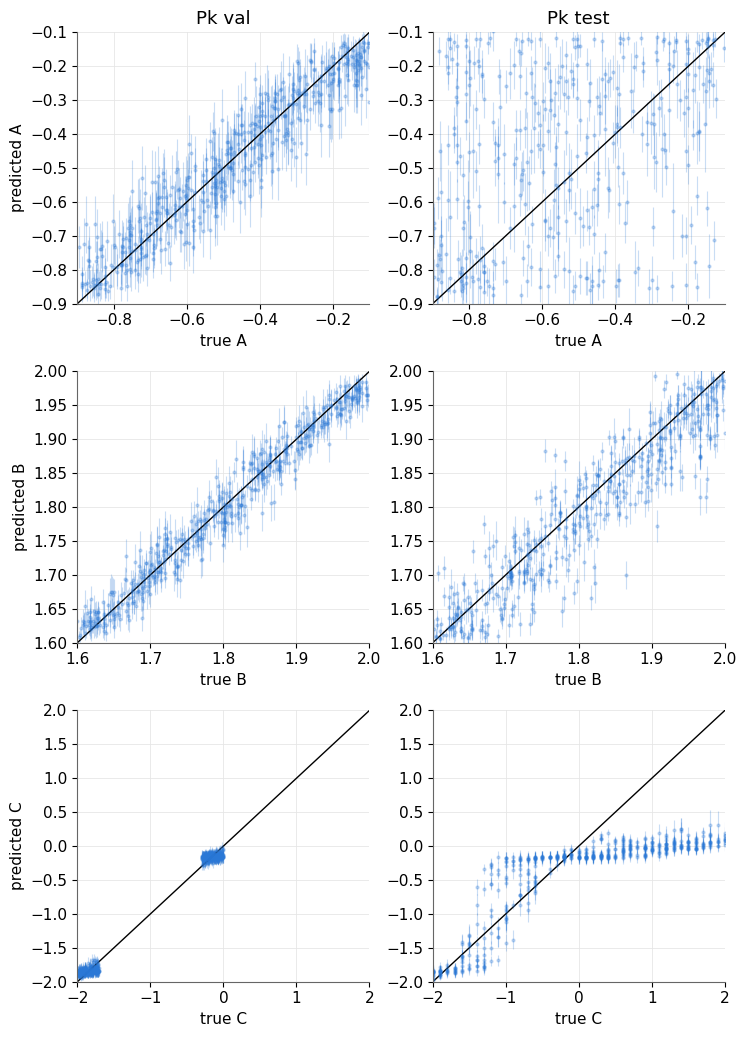

In [5]:
fig = plots.true_vs_pred(cfg, results); metrics.save_fig(cfg, fig, f"sbi_{KIND}/true_vs_pred")

## Error, width and bias distributions (solid = val, dashed = C-grid test)
The first/last bins also collect the values outside the plotted range.

PosixPath('outputs/full/sbi_pk/error_distributions.png')

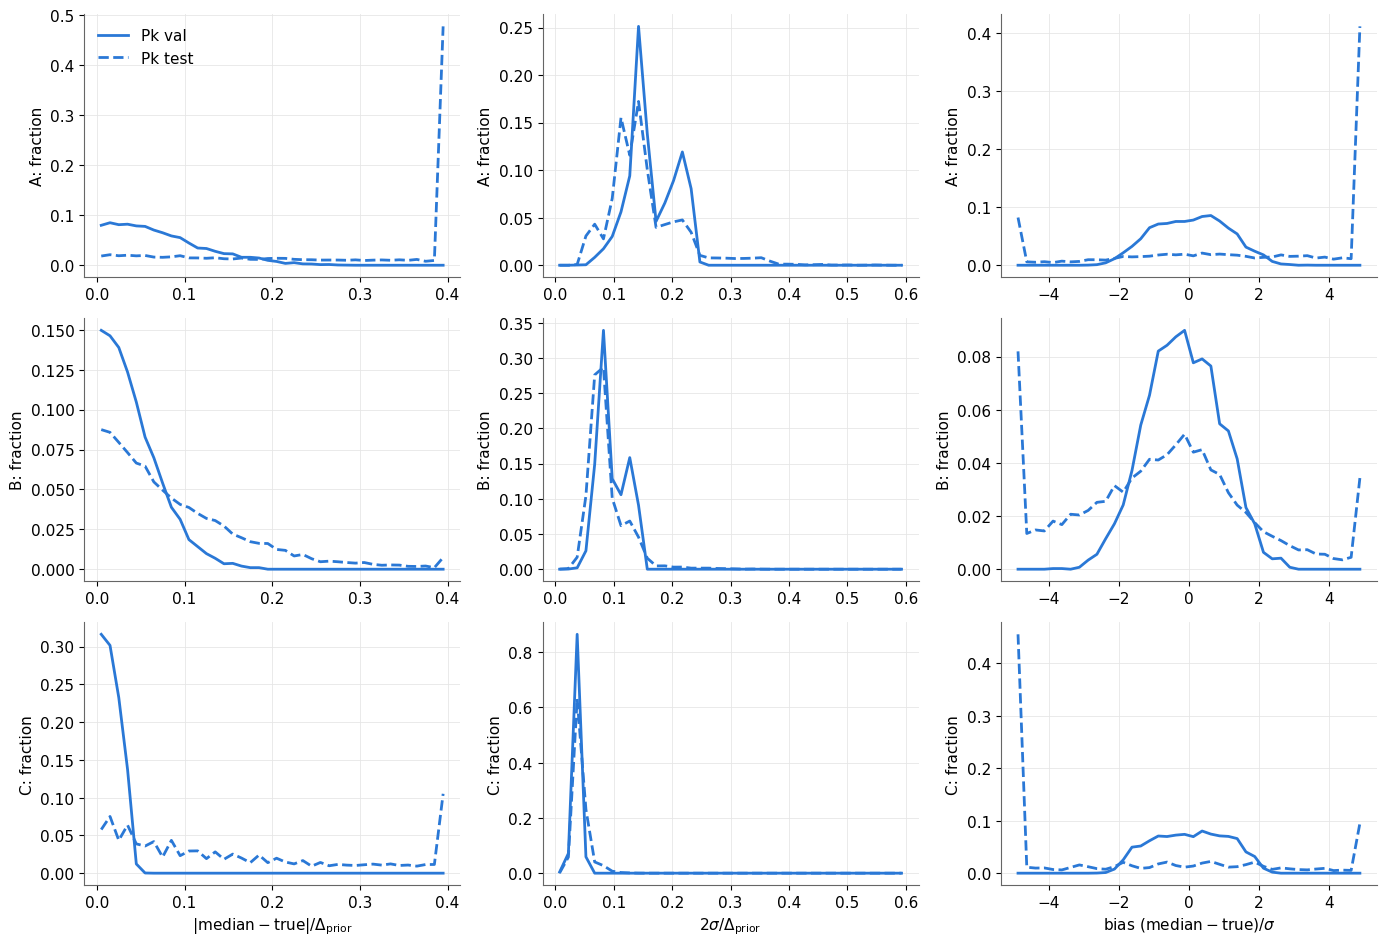

In [6]:
fig = plots.error_distributions(cfg, results); metrics.save_fig(cfg, fig, f"sbi_{KIND}/error_distributions")

## Coverage (calibration)

PosixPath('outputs/full/sbi_pk/coverage.png')

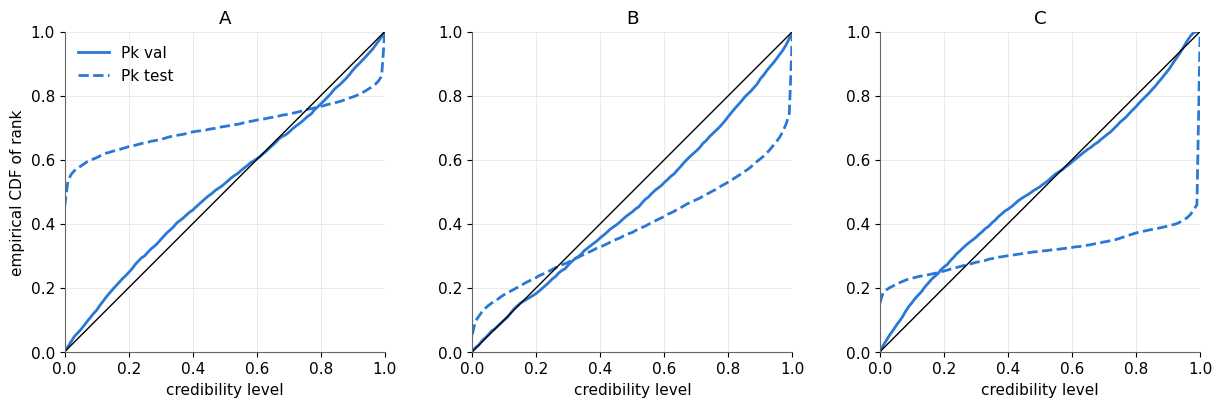

In [7]:
fig = plots.coverage(cfg, results); metrics.save_fig(cfg, fig, f"sbi_{KIND}/coverage")

## Metrics as a function of C (C-grid test set; grey = C ranges seen in training)

PosixPath('outputs/full/sbi_pk/metrics_vs_C.png')

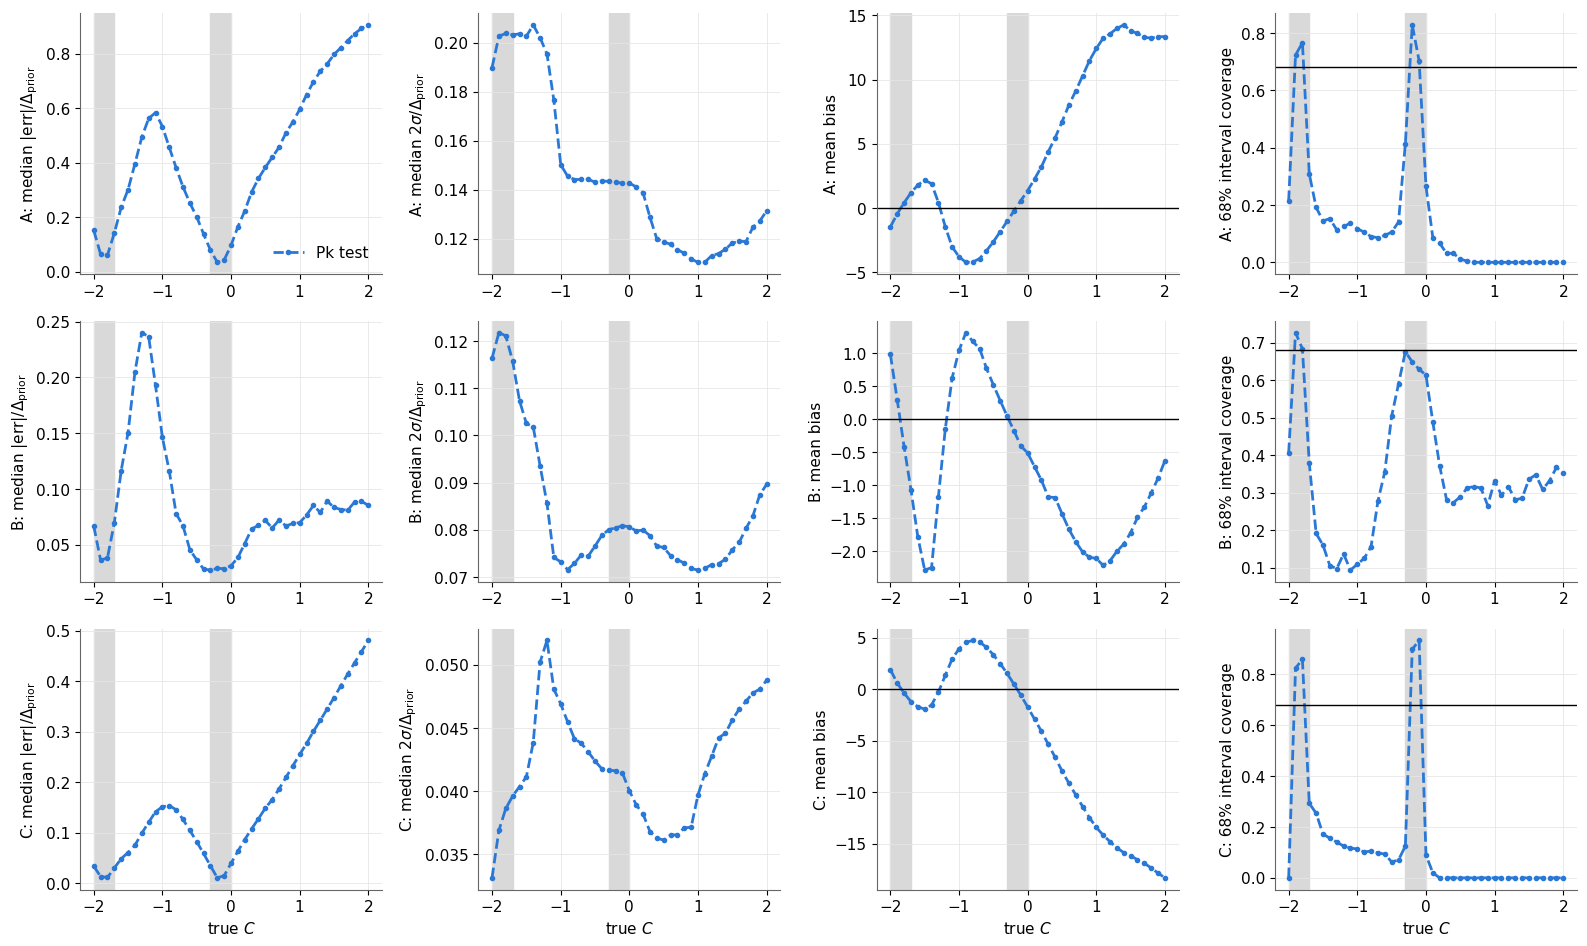

In [8]:
fig = plots.metrics_vs_c(cfg, {f"{LABEL} test": results[f"{LABEL} test"]})
metrics.save_fig(cfg, fig, f"sbi_{KIND}/metrics_vs_C")